Dataset Shape: (50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


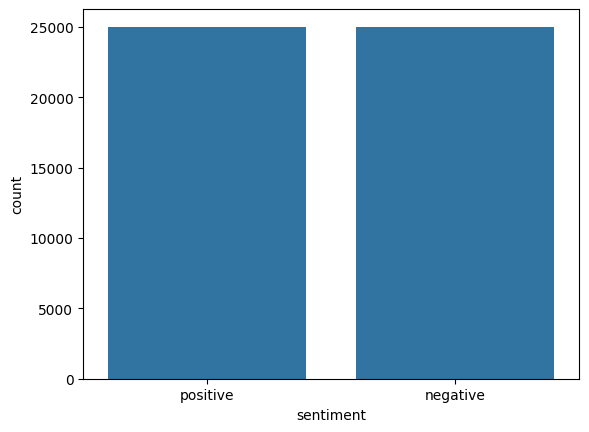

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

url = "https://raw.githubusercontent.com/Ankit152/IMDB-sentiment-analysis/master/IMDB-Dataset.csv"
print("Downloading dataset...") 

imdb = pd.read_csv(url)

print(f"Dataset Shape: {imdb.shape}")
print(imdb.head())

#checking balance 
sns.countplot(x='sentiment', data=imdb)
plt.show() 

In [2]:
import re
from sklearn.model_selection import train_test_split

#defining the cleaning function
def clean_text(text):
    #removing html tags
    text = re.sub(r'<.*?>', '', text)
    #removing non-alphabetic characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    #converting to lowercase
    text = text.lower()
    return text


In [3]:
#applying chnages to dataset
print("Cleaning text...")
imdb['cleaned_review'] = imdb['review'].apply(clean_text)


Cleaning text...


In [4]:
#checking the difference
print("\n--- Original ---")
print(imdb['review'].iloc[0][:100])
print("\n--- Cleaned ---")
print(imdb['cleaned_review'].iloc[0][:100])


--- Original ---
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. The

--- Cleaned ---
one of the other reviewers has mentioned that after watching just  oz episode youll be hooked they a


In [5]:
#splitting into train/test
#using standard 80/20 split
x = imdb['cleaned_review']
y = imdb['sentiment']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(f"\nTraining on {len(x_train)} reviews, Testing on {len(x_test)} reviews.")


Training on 40000 reviews, Testing on 10000 reviews.


In [11]:
#vectorization (tf-idf)
from sklearn.feature_extraction.text import TfidfVectorizer
#intializing the vectorizer
#max_features=5000 (this prevents my machine from crashing [extend to 50000 if you have an excellent machine])
#stop_words='english': removing words like 'the, 'is', at'
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
print("Vectorizing data...") 


Vectorizing data...


In [12]:
#fit and transform
#learning from training data only, then apply to both
x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf = tfidf.transform(x_test) 
print(f"Shape of Training Matrix: {x_train_tfidf.shape}")
print(f"Shape of Testing Matrix: {x_test_tfidf.shape}") 

Shape of Training Matrix: (40000, 5000)
Shape of Testing Matrix: (10000, 5000)


In [13]:
#using naive bayes algorithm
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

#initialization and training
nb_model = MultinomialNB()
nb_model.fit(x_train_tfidf, y_train) 

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [14]:
#prediction on test set
y_pred = nb_model.predict(x_test_tfidf)

In [16]:
#evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}")
print("\n--- Detailed Report ---")
print(classification_report(y_test, y_pred))

Model Accuracy: 84.77%

--- Detailed Report ---
              precision    recall  f1-score   support

    negative       0.85      0.84      0.85      4961
    positive       0.85      0.85      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



In [17]:
def predict_sentiment(raw_review):
    cleaned = clean_text(raw_review)
    #vectorize (rransform only! do NOT fit!)
    vectorized = tfidf.transform([cleaned])
    #prediction
    prediction = nb_model.predict(vectorized)[0]
    #getting probability
    proba = nb_model.predict_proba(vectorized).max() * 100

    return f"Verdict: {prediction.upper()} ({proba:.2}% confident)"

In [26]:
#running tests
review1 = "I absolutely loved this film!"
review2 = "Horrible Movie!"
review3 = "It was okay, i guess! Could be better!"

print(f"Review 1: {predict_sentiment(review1)}")
print(f"Review 2: {predict_sentiment(review2)}")
print(f"Review 3: {predict_sentiment(review3)}")

Review 1: Verdict: POSITIVE (6.7e+01% confident)
Review 2: Verdict: NEGATIVE (8.7e+01% confident)
Review 3: Verdict: NEGATIVE (7.6e+01% confident)


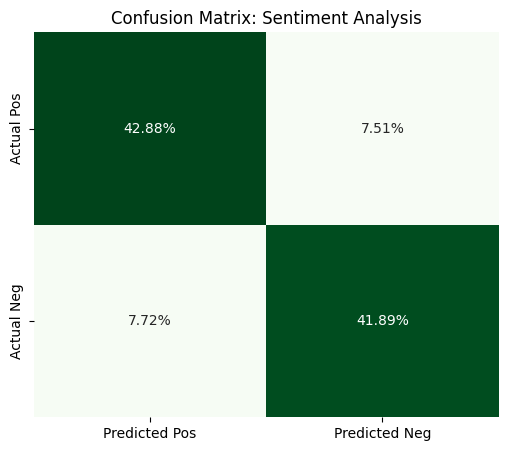

In [27]:
from sklearn.metrics import confusion_matrix
#adding confusion matrix visuals
cm_imdb = confusion_matrix(y_test, y_pred, labels=['positive', 'negative'])
cm_percent = cm_imdb.astype('float') / cm_imdb.sum()

plt.figure(figsize=(6,5))
sns.heatmap(cm_percent, annot=True, fmt='.2%', cmap='Greens', cbar=False,
            xticklabels=['Predicted Pos', 'Predicted Neg'],
            yticklabels=['Actual Pos', 'Actual Neg'])
plt.title('Confusion Matrix: Sentiment Analysis')
plt.show() 